<a href="https://colab.research.google.com/github/Alokkori/DSML_AUG_2024/blob/main/Logistic_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **LogisticRegression with Hyperperameter**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

!gdown 1uUt7uL-VuF_5cpodYRiriEwhsldeEp3m

import pandas as pd
churn = pd.read_csv("churn_logistic.csv")
churn.head()

Downloading...
From: https://drive.google.com/uc?id=1uUt7uL-VuF_5cpodYRiriEwhsldeEp3m
To: /content/churn_logistic.csv
100% 494k/494k [00:00<00:00, 5.18MB/s]


,Account Length,VMail Message,Day Mins,Eve Mins,Night Mins,Intl Mins,CustServ Calls,Intl Plan,VMail Plan,Day Calls,...,Eve Calls,Eve Charge,Night Calls,Night Charge,Intl Calls,Intl Charge,State,Area Code,Phone,Churn
0,128,25,265.1,197.4,244.7,10.0,1,0,1,110,...,99,16.78,91,11.01,3,2.70,KS,415,382-4657,0
1,107,26,161.6,195.5,254.4,13.7,1,0,1,123,...,103,16.62,103,11.45,3,3.70,OH,415,371-7191,0
2,137,0,243.4,121.2,162.6,12.2,0,0,0,114,...,110,10.30,104,7.32,5,3.29,NJ,415,358-1921,0
3,84,0,299.4,61.9,196.9,6.6,2,1,0,71,...,88,5.26,89,8.86,7,1.78,OH,408,375-9999,0
4,75,0,166.7,148.3,186.9,10.1,3,1,0,113,...,122,12.61,121,8.41,3,2.73,OK,415,330-6626,0


In [ ]:
cols = ['Day Mins','Eve Mins','Night Mins','CustServ Calls','Account Length']
y = churn['Churn']
y = np.array(y).reshape(len(y),1)
X = churn[cols]
X.shape


(5700, 5)

In [ ]:
from sklearn.model_selection import train_test_split
X_tr_cv, X_test, y_tr_cv, y_test_cv = train_test_split(X,y,test_size=0.2, random_state=1)
X_train, X_val, y_train, y_val = train_test_split(X_tr_cv, y_tr_cv, test_size=0.25,random_state=1)
X_train.shape

(3420, 5)

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X_train)

X_train = scaler.fit_transform(X_train)
X_val = scaler.fit_transform(X_val)
X_test = scaler.fit_transform(X_test)

In [ ]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X_train, y_train)

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


LogisticRegression()

In [ ]:
print('coef=',model.coef_)
print('intercept=',model.intercept_)

coef= [[0.68445262 0.29104301 0.1363756  0.79630985 0.06125924]]
intercept= [-0.01220319]


In [ ]:
model.score(X_train,y_train)

0.7058479532163743

In [ ]:
model.score(X_val,y_val)

0.7105263157894737

**Logistic_R with Binery_class**

In [ ]:
def accuracy(y_true, y_pred):
  y_true = y_true.reshape(len(y_true))
  return np.sum(y_true==y_pred)/y_true.shape[0]

In [ ]:
from sklearn.pipeline import make_pipeline
train_scores = []
val_scores = []
scaler = StandardScaler()
for la in np.arange(0.01,3000.0,100):
  scaled_lr = make_pipeline(scaler,LogisticRegression(C=1/la)) # C is a lambda value
  scaled_lr.fit(X_train,y_train)
  train_score = accuracy(y_train,scaled_lr.predict(X_train))
  val_score = accuracy(y_val,scaled_lr.predict(X_val))
  train_scores.append(train_score)
  val_scores.append(val_score)

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for exam

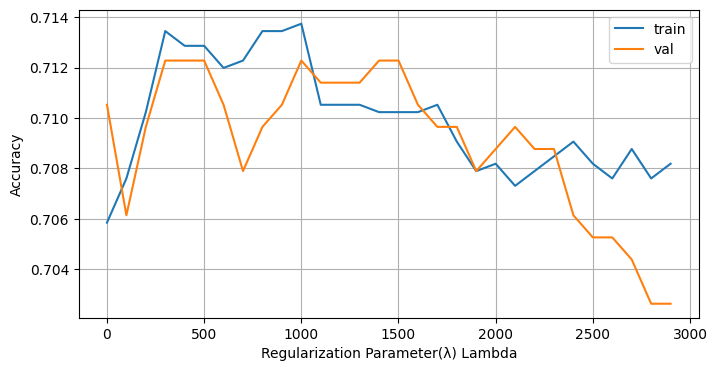

In [ ]:
plt.figure(figsize=(8,4))
plt.plot(list(np.arange(0.01, 3000.0, 100)), train_scores, label="train")
plt.plot(list(np.arange(0.01, 3000.0, 100)), val_scores, label="val")
plt.legend(loc='upper right')

plt.xlabel("Regularization Parameter(λ) Lambda")
plt.ylabel("Accuracy")
plt.grid()
plt.show()

## **LogisticRegression_Mulitclass_Classification**

**Confusion_Matrics**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
!gdown 1CgBW5H54YfdYtJmYE5GWctaHZSpFt71V

Downloading...
From: https://drive.google.com/uc?id=1CgBW5H54YfdYtJmYE5GWctaHZSpFt71V
To: /content/spam_ham_dataset.csv
100% 5.50M/5.50M [00:00<00:00, 38.7MB/s]


In [ ]:
demo1 = pd.read_csv('spam_ham_dataset.csv')
demo1.drop(['Unnamed: 0','label'],axis=1,inplace=True)
demo1.head()

,text,label_num
0,Subject: enron methanol ; meter # : 988291\r\n...,0
1,"Subject: hpl nom for january 9 , 2001\r\n( see...",0
2,"Subject: neon retreat\r\nho ho ho , we ' re ar...",0
3,"Subject: photoshop , windows , office . cheap ...",1
4,Subject: re : indian springs\r\nthis deal is t...,0


In [ ]:
!gdown 1dw56R8SzKgTgiKurfBLUTxmiewJacMkt

Downloading...
From: https://drive.google.com/uc?id=1dw56R8SzKgTgiKurfBLUTxmiewJacMkt
To: /content/Spam_finalData.csv
100% 1.64M/1.64M [00:00<00:00, 17.6MB/s]


In [ ]:
df = pd.read_csv('Spam_finalData.csv')

In [ ]:
df.head()

,label_num,Feature0,Feature1,Feature2,Feature3,Feature4,Feature5,Feature6,Feature7,Feature8,Feature9,Feature10,Feature11,Feature12,Feature13,Feature14
0,0,-0.031489,-0.003323,-0.071238,0.047743,0.060798,0.046597,-0.069530,-0.000031,-0.037924,0.024059,-0.015085,-0.007752,-0.021617,-0.025395,0.046050
1,0,-0.122601,0.114176,0.460451,0.000953,0.014707,0.007610,-0.011173,-0.052478,0.040209,0.000076,0.010306,0.023397,-0.007294,0.063543,0.081119
2,0,-0.076681,-0.084330,-0.054658,-0.048236,-0.019999,-0.045909,-0.004712,-0.001524,0.013735,-0.022429,0.010273,-0.007458,-0.044340,-0.051093,0.025553
3,1,-0.075948,-0.059706,-0.025301,-0.037603,-0.001208,-0.030660,0.018873,-0.013434,-0.014981,0.000741,0.005653,0.032153,0.001884,-0.018005,-0.011060
4,0,-0.054680,0.033033,-0.090885,-0.047280,-0.029304,0.085893,-0.105351,-0.053915,-0.006857,0.021673,0.056718,0.006140,0.042217,0.018862,-0.007373


In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(df.drop(['label_num'],axis=1),df['label_num'])

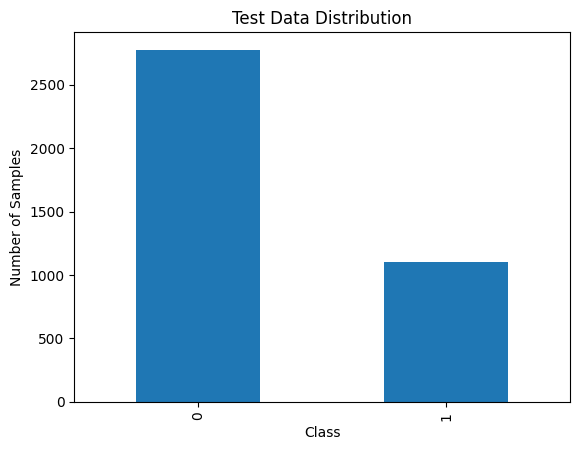

In [ ]:
y_train.value_counts().plot(kind='bar')
plt.xlabel('Class')
plt.ylabel('Number of Samples')
plt.title('Test Data Distribution')
plt.show()

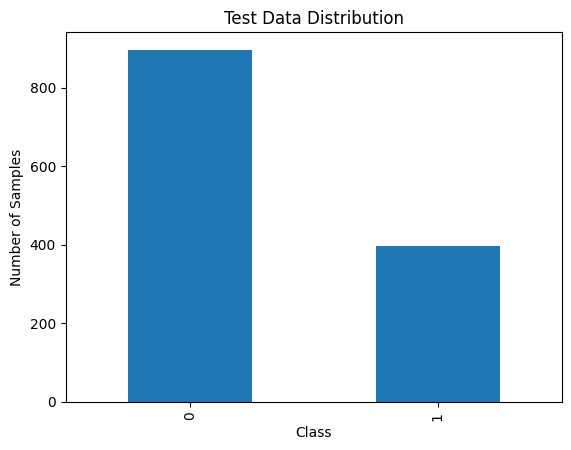

In [ ]:
y_test.value_counts().plot(kind='bar')
plt.xlabel('Class')
plt.ylabel('Number of Samples')
plt.title('Test Data Distribution')
plt.show()

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
model = LogisticRegression()
model.fit(X_train,y_train)

LogisticRegression()

In [ ]:
print('accuracy_metrics=',model.score(X_test,y_test))

accuracy_metrics= 0.934261407579273


In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = model.predict(X_test)
conf_matrics = confusion_matrix(y_test,y_pred)
conf_matrics

array([[830,  66],
       [ 19, 378]])

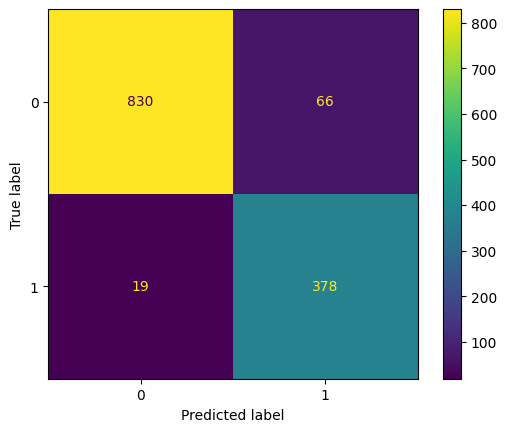

In [ ]:
import matplotlib.pyplot as plt
ConfusionMatrixDisplay(conf_matrics).plot()

In [ ]:
# accuracy_score = (TP+TN)/(TP+TN+FP+FN)
np.diag(conf_matrics).sum()/(conf_matrics).sum()

np.float64(0.934261407579273)

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score
print('precision=',precision_score(y_test,y_pred))
print('recall=',recall_score(y_test,y_pred))
print('f1_score=',f1_score(y_test,y_pred))

precision= 0.8513513513513513
recall= 0.9521410579345088
f1_score= 0.8989298454221165


**ROC  Reciver_Oprating_Charecterstic**

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

In [ ]:
prob = model.predict_proba(X_test)
prob

array([[0.49165456, 0.50834544],
       [0.46781713, 0.53218287],
       [0.997717  , 0.002283  ],
       ...,
       [0.9538125 , 0.0461875 ],
       [0.96633979, 0.03366021],
       [0.81527028, 0.18472972]])

In [ ]:
probabilities = prob[:,1]
probabilities

array([0.50834544, 0.53218287, 0.002283  , ..., 0.0461875 , 0.03366021,
       0.18472972])

In [ ]:
fpr,tpr,thr = roc_curve(y_test,probabilities)

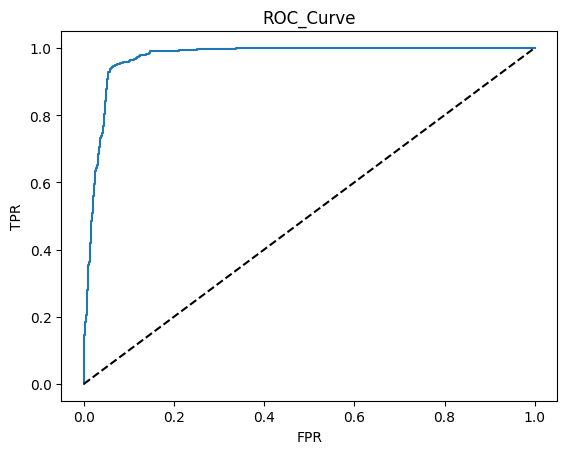

In [ ]:
plt.plot(fpr,tpr)
plt.plot(fpr,fpr,'--',color = 'black')
plt.title('ROC_Curve')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.show()

In [ ]:
auc = roc_auc_score(y_test,probabilities)
print(auc)

0.9720813467074487


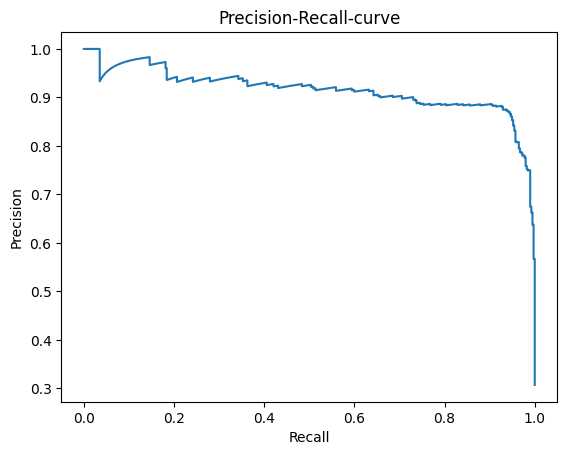

In [ ]:
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import auc

precision, recall, thr = precision_recall_curve(y_test, probabilities)

plt.plot(recall, precision)

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall-curve')
plt.show()

In [ ]:
auc( recall,precision)

np.float64(0.9159023320124103)

In [ ]:
y_train.value_counts()

,count
label_num,
0,2776
1,1102


In [ ]:
2783/1095

2.5415525114155253

In [ ]:
model = LogisticRegression(class_weight={0:1,1:2.54})

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
model.fit(X_train,y_train)
y_pred = model.predict(X_test)
conf_matrics = confusion_matrix(y_test,y_pred)

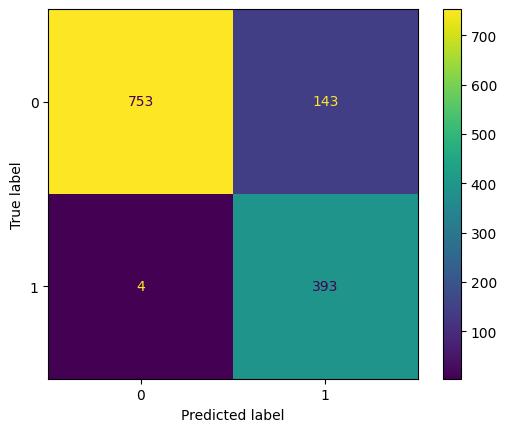

In [ ]:
ConfusionMatrixDisplay(conf_matrics).plot()
plt.show()

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score
from imblearn.over_sampling import RandomOverSampler

In [ ]:
def training(model,X_train,y_train,X_test,y_test):
  model.fit(X_train,y_train)
  train_y_pred = model.predict(X_train)
  test_y_pred = model.predict(X_test)

  train_score = f1_score(y_train, train_y_pred)
  test_score = f1_score(y_test, test_y_pred)

  return train_score,test_score

In [ ]:
oversampling = RandomOverSampler()

In [ ]:
print('Before sampling')
print(y_train.value_counts())
X_train_oversampled, y_train_oversampled = oversampling.fit_resample(X_train, y_train)

print('After Oversampling')
print(y_train_oversampled.value_counts())

Before sampling
label_num
0    2776
1    1102
Name: count, dtype: int64
After Oversampling
label_num
0    2776
1    2776
Name: count, dtype: int64


In [ ]:
model = LogisticRegression()
f1_train,f1_test = training(model,X_train_oversampled, y_train_oversampled, X_test,y_test)
print(f'training_f1_score: {f1_score},testing_score:{f1_score}')

training_f1_score: <function f1_score at 0x78052d9a5b20>,testing_score:<function f1_score at 0x78052d9a5b20>


**SMOTE**

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score
from imblearn.over_sampling import SMOTE

In [ ]:
smt = SMOTE()

In [ ]:
print('before sampling:' )
print(y_train.value_counts())

X_smt, y_smt = smt.fit_resample(X_train,y_train)
print('after sampling:')
print(y_train.value_counts())

model = LogisticRegression(C= 5,penalty = 'l1',solver = 'liblinear')

f1_train,f1_test = training(model,X_smt,y_smt,X_test,y_test)
print(f'Training f1_score:{f1_train}, Testing f1 score:{f1_test}')


before sampling:
label_num
0    2776
1    1102
Name: count, dtype: int64
after sampling:
label_num
0    2776
1    1102
Name: count, dtype: int64
Training f1_score:0.9548568417354646, Testing f1 score:0.9105691056910569
